In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 주피터 노트북에서 그래프를 바로 볼 수 있게 하는 매직 커맨드
%matplotlib inline

# 한글 폰트 설정 (필요시 주석 해제)
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# CSV 파일 경로 설정
csv_path = "C:/Users/SSAFY/sj/pjt/pjt02/금융/archive/NFLX.csv"

# 데이터 불러오기
df = pd.read_csv(csv_path, usecols=range(0, 5))

# 날짜 데이터 변환
df["Date"] = pd.to_datetime(df["Date"])

# 데이터 확인
print(df)

           Date        Open        High         Low       Close
0    2018-02-05  262.000000  267.899994  250.029999  254.259995
1    2018-02-06  247.699997  266.700012  245.000000  265.720001
2    2018-02-07  266.579987  272.450012  264.329987  264.559998
3    2018-02-08  267.079987  267.619995  250.000000  250.100006
4    2018-02-09  253.850006  255.800003  236.110001  249.470001
...         ...         ...         ...         ...         ...
1004 2022-01-31  401.970001  427.700012  398.200012  427.140015
1005 2022-02-01  432.959991  458.480011  425.540009  457.130005
1006 2022-02-02  448.250000  451.980011  426.480011  429.480011
1007 2022-02-03  421.440002  429.260010  404.279999  405.600006
1008 2022-02-04  407.309998  412.769989  396.640015  410.170013

[1009 rows x 5 columns]


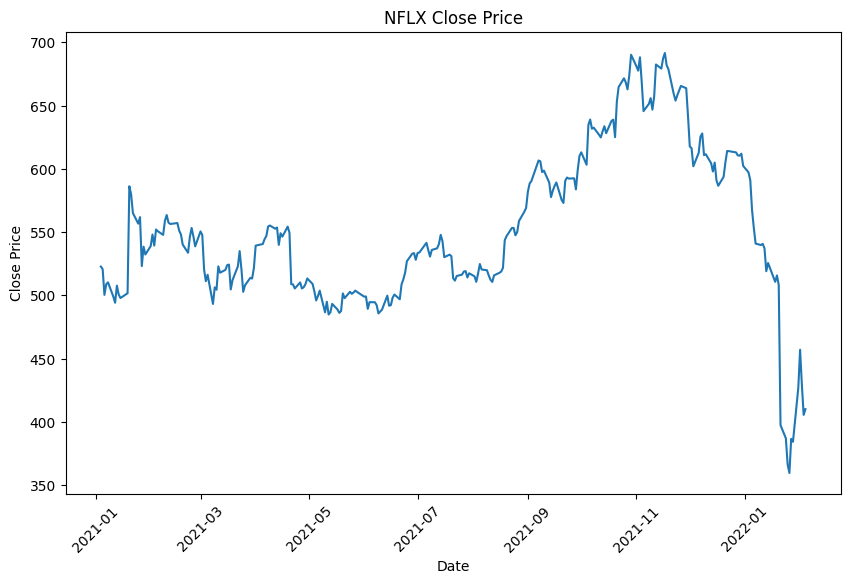

In [5]:
# 1. 2021년~2022년 2월 데이터 필터링 및 시각화
df_range = df[df['Date'].between('2021-01-01','2022-02-04')]

plt.figure(figsize=(10, 6))
plt.plot(df_range['Date'], df_range['Close'])

plt.title('NFLX Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.show()

In [6]:
# 최고/최저 종가 출력
df_max = df_range['Close'].max()
df_min = df_range['Close'].min()
print("최고 종가:", df_max)
print("최저 종가:", df_min)

최고 종가: 691.690002
최저 종가: 359.700012


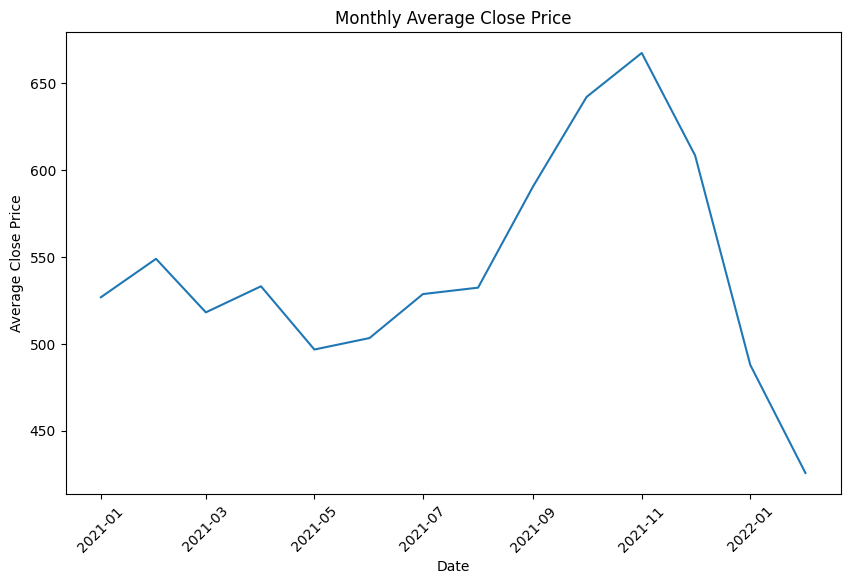

In [7]:
# 2. 월별 평균 종가 계산 및 시각화
monthly_data = df_range.groupby(df_range['Date'].dt.strftime('%Y-%m'))['Close'].mean()

# 인덱스를 날짜형으로 변환 (그래프 정렬용)
monthly_data.index = pd.to_datetime(monthly_data.index)

plt.figure(figsize=(10, 6))
plt.plot(monthly_data)

plt.title('Monthly Average Close Price')
plt.xlabel('Date')
plt.ylabel('Average Close Price')
plt.xticks(rotation=45)
plt.show()

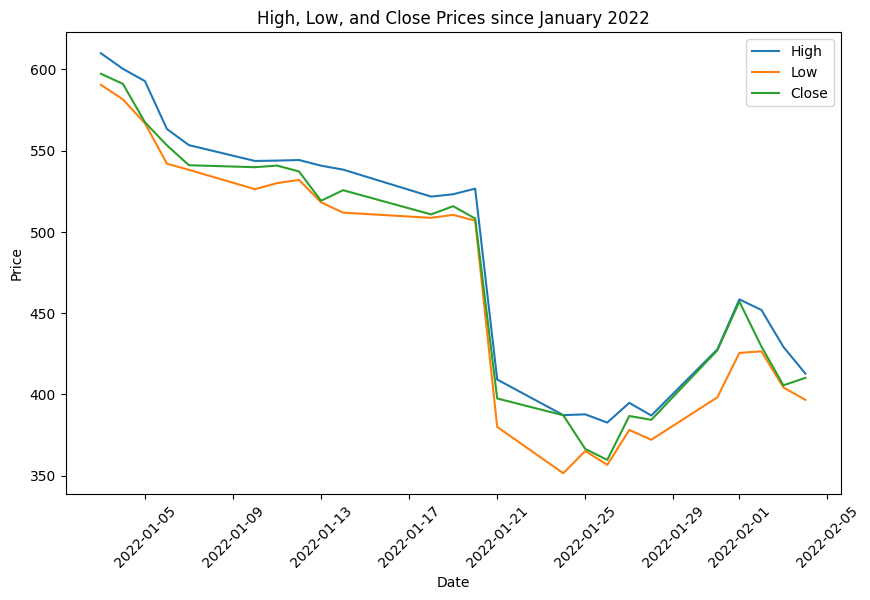

In [8]:
# 3. 2022년 이후 High, Low, Close 시각화
df_2022 = df[df['Date'] >= '2022-01-01']

plt.figure(figsize=(10, 6))

# 그래프 그리기
plt.plot(df_2022['Date'], df_2022['High'], label='High')
plt.plot(df_2022['Date'], df_2022['Low'], label='Low')
plt.plot(df_2022['Date'], df_2022['Close'], label='Close')

plt.title('High, Low, and Close Prices since January 2022')
plt.xlabel('Date') 
plt.ylabel('Price')

# 범례 및 축 설정
plt.legend()
plt.xticks(rotation=45)

plt.show()